# Tutorial 01 — The Classical Machine Learning Paradigm

### From Machine Learning to Foundation Models · Hands-On AI for Power & Energy Systems

> **How did machine learning work before deep learning?**

---

## 1. Why this matters

Almost every machine-learning system deployed in a control room today follows
the pattern in this notebook: somebody picked a dataset, somebody engineered
features, somebody trained a model for one task, and somebody evaluated it.
The rest of this course is the story of how that pattern was progressively
dismantled — first the features became learned, then the task became optional
at training time, then the dataset became a whole domain. You cannot
appreciate any of that without first doing it the old way, properly.

"Properly" is doing a lot of work in that sentence. This notebook spends as
much effort on **splitting**, **leakage** and **baselines** as on the models
themselves, because those are where energy-forecasting results most often go
wrong — and because a leaked result in tutorial 01 would make every comparison
in tutorials 02 through 10 meaningless.

## 2. Historical context

Roughly 1990–2012. Statistical learning theory matured, kernel methods and
ensembles of trees dominated applied work, and the winning move in any
competition was better features, not a bigger model. Random forests (Breiman,
2001) and gradient boosting (Friedman, 2001) are from this era and are *still*
the correct default for small tabular problems in 2026 — a fact this course
will return to repeatedly.

## 3. Learning objectives

By the end of this notebook you can:

- frame a power-system problem as observations, features and labels;
- build a **chronological** train/validation/test split, and explain what a
  random split does to a time series;
- name at least three ways data leaks in energy forecasting, and detect one;
- fit and compare linear regression, decision trees, random forests and
  gradient boosting;
- read bias–variance behaviour off a validation curve;
- argue why a strong trivial baseline is the only meaningful reference point;
- check whether a statistically good forecast is *physically* possible.

In [1]:
from __future__ import annotations

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.base import clone
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

from ai_power_course import diagrams
from ai_power_course.config import fast_mode, scaled, set_seed
from ai_power_course.data import load_energy_data, make_supervised, time_split
from ai_power_course.metrics import mae, physical_violations, point_metrics, rmse, skill_score
from ai_power_course.models.baselines import baseline_suite
from ai_power_course.plotting import COLORS, plot_error_by_hour, plot_forecast, use_course_style
from ai_power_course.results import Leaderboard, leaderboard_table, record

warnings.filterwarnings("ignore", category=FutureWarning)
use_course_style()
set_seed()

print(f"reduced (CI) configuration: {fast_mode()}")

reduced (CI) configuration: False


## 4. Theory

### The supervised learning setup

We are given $n$ observations $(\mathbf{x}_i, y_i)$ and we look for a function
$f$ such that $f(\mathbf{x}_i) \approx y_i$, chosen from a hypothesis class
$\mathcal{F}$ by minimising a loss:

$$\hat f = \arg\min_{f \in \mathcal{F}} \; \frac{1}{n}\sum_{i=1}^{n} L\big(y_i, f(\mathbf{x}_i)\big) \;+\; \lambda\,\Omega(f)$$

Three choices, all of them ours to make:

| Choice | Symbol | For day-ahead load forecasting |
|---|---|---|
| features | $\mathbf{x}$ | lags, calendar, weather — **engineered by a human** |
| hypothesis class | $\mathcal{F}$ | linear? trees? an ensemble? |
| loss | $L$ | squared error (penalises big misses), absolute error (robust) |

### Bias, variance and the reason we need three splits

For squared loss the expected test error decomposes into

$$\mathbb{E}\big[(y - \hat f(\mathbf{x}))^2\big] = \underbrace{\text{Bias}^2}_{\text{too simple}} + \underbrace{\text{Variance}}_{\text{too sensitive to this sample}} + \underbrace{\sigma^2}_{\text{irreducible}}$$

A model complex enough to drive bias to zero will have high variance and
memorise the training set. We therefore need a *third* dataset: training fits
the parameters, validation chooses the complexity, and test — touched exactly
once — estimates performance. The moment you tune on the test set, it becomes
a validation set and you no longer have an estimate of generalisation.

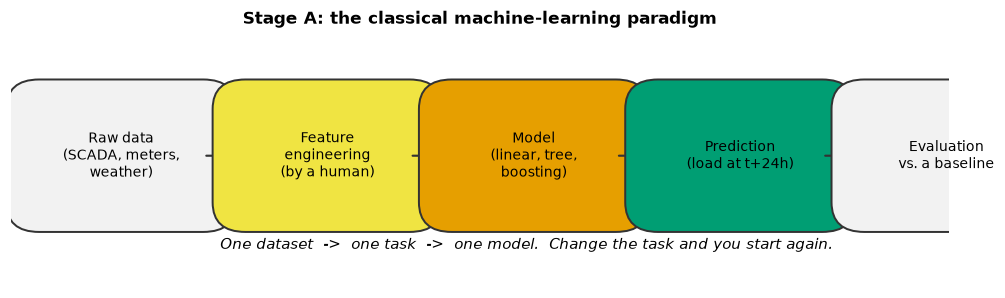

In [2]:
fig = diagrams.supervised_pipeline()
plt.show()

## 5. The data

The course uses one recurring dataset so that every model in tutorials 01–09
is directly comparable. Before anything else: **where does it come from?**

In [3]:
dataset = load_energy_data()
print(dataset.describe())

DATA PROVENANCE: SIMULATED (not measurements)
  source   : synthetic
  title    : Synthetic European power-system time series (ai_power_course.synthetic)
  license  : MIT (generated by this repository)
  cite as  : Generated by ai_power_course.synthetic.generate_energy_frame, seed 20260101.
  notes    : Physically motivated simulation. Magnitudes are tuned to resemble Germany (~479 TWh/a load, PV CF 0.12, wind CF 0.20) but no value is a measurement.
rows      : 35,064 (2017-01-01 to 2020-12-31, h)
columns   : load_mw, pv_mw, wind_mw, residual_load_mw, price_eur_mwh, temperature_c, wind_speed_ms, clear_sky_index, is_weekend, is_holiday


Read that banner. The default dataset is a **simulation**, not measurements —
it is built from solar geometry, a wind power curve and a temperature-driven
load model in `ai_power_course.synthetic`. It is shipped with the repository
because the real equivalent (Open Power System Data, derived from ENTSO-E
Transparency) cannot be freely redistributed; see `data/README.md`.

Every experiment in this course runs unchanged on the real data:

```bash
uv run python scripts/download_data.py     # then load_energy_data() picks it up
```

Presenting simulated numbers as measurements would be a research-integrity
failure, which is why the provenance travels with the data rather than living
in a README nobody reads.

In [4]:
frame = dataset.frame
display(frame.head(3))
print(f"\n{len(frame):,} hourly observations, {frame.index[0]:%Y-%m-%d} to {frame.index[-1]:%Y-%m-%d}")
print(f"\nAnnual energy: load {frame.load_mw.sum() / 1e6 / 4:.0f} TWh/a, "
      f"PV {frame.pv_mw.sum() / 1e6 / 4:.0f} TWh/a, wind {frame.wind_mw.sum() / 1e6 / 4:.0f} TWh/a")

,load_mw,pv_mw,wind_mw,residual_load_mw,price_eur_mwh,temperature_c,wind_speed_ms,clear_sky_index,is_weekend,is_holiday
time,,,,,,,,,,
2017-01-01 00:00:00+00:00,45411.327,0.0,15937.635,29473.692,43.652,4.078,9.058,0.0,True,True
2017-01-01 01:00:00+00:00,48092.035,0.0,24252.764,23839.271,36.899,3.660,9.968,0.0,True,True
2017-01-01 02:00:00+00:00,50777.836,0.0,22175.873,28601.964,31.187,2.811,9.764,0.0,True,True



35,064 hourly observations, 2017-01-01 to 2020-12-31

Annual energy: load 479 TWh/a, PV 46 TWh/a, wind 98 TWh/a


### Look at the data before modelling it

This is not a formality. The three seasonalities visible below (daily, weekly,
annual) determine every feature we build, and the hard zeros in PV determine
whether a forecast is physically admissible.

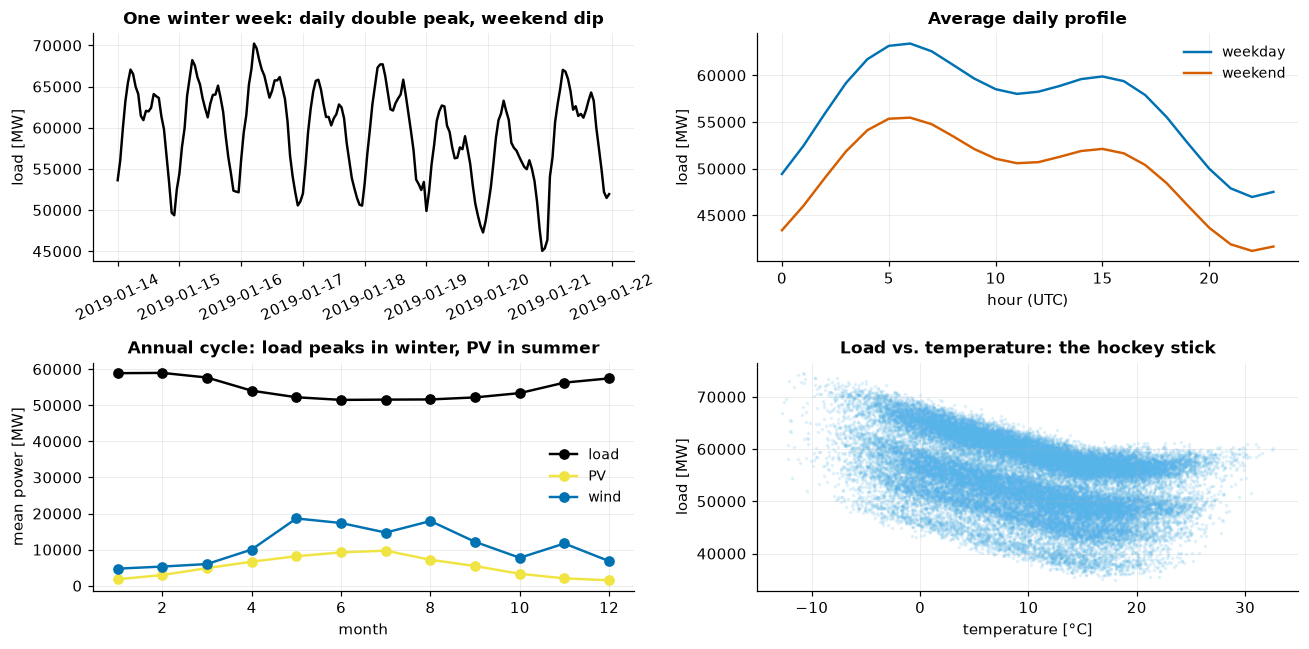

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

week = frame.loc["2019-01-14":"2019-01-21"]
axes[0, 0].plot(week.index, week.load_mw, color=COLORS["truth"])
axes[0, 0].set_title("One winter week: daily double peak, weekend dip")
axes[0, 0].set_ylabel("load [MW]")
axes[0, 0].tick_params(axis="x", rotation=25)

hourly = frame.groupby([frame.index.dayofweek >= 5, frame.index.hour]).load_mw.mean().unstack(0)
axes[0, 1].plot(hourly.index, hourly[False], label="weekday", color=COLORS["rnn"])
axes[0, 1].plot(hourly.index, hourly[True], label="weekend", color=COLORS["transformer"])
axes[0, 1].set_title("Average daily profile")
axes[0, 1].set_xlabel("hour (UTC)")
axes[0, 1].set_ylabel("load [MW]")
axes[0, 1].legend()

monthly = frame.groupby(frame.index.month)[["load_mw", "pv_mw", "wind_mw"]].mean()
axes[1, 0].plot(monthly.index, monthly.load_mw, marker="o", label="load", color=COLORS["truth"])
axes[1, 0].plot(monthly.index, monthly.pv_mw, marker="o", label="PV", color=COLORS["accent"])
axes[1, 0].plot(monthly.index, monthly.wind_mw, marker="o", label="wind", color=COLORS["rnn"])
axes[1, 0].set_title("Annual cycle: load peaks in winter, PV in summer")
axes[1, 0].set_xlabel("month")
axes[1, 0].set_ylabel("mean power [MW]")
axes[1, 0].legend()

axes[1, 1].scatter(frame.temperature_c, frame.load_mw, s=2, alpha=0.12, color=COLORS["mlp"])
axes[1, 1].set_title("Load vs. temperature: the hockey stick")
axes[1, 1].set_xlabel("temperature [°C]")
axes[1, 1].set_ylabel("load [MW]")

fig.tight_layout()
plt.show()

The bottom-right panel is why linear regression on raw temperature cannot
work: the relationship is V-shaped (heating below ~15 °C, cooling above
~22 °C), so a single slope averages two opposite effects into nothing. Either
engineer the non-linearity into the features, or use a model class that can
represent it. That choice is the whole of classical ML in one picture.

## 6. The task, and the split

**Task:** predict system load 24 hours ahead. This is the course-wide
benchmark; tutorials 02, 03, 06 and 09 attack exactly the same problem.

A day-ahead horizon is chosen deliberately. At a one-hour horizon persistence
is nearly unbeatable and nothing interesting happens; at 24 hours the model
must actually understand the daily cycle.

In [6]:
HORIZON = 24
train_raw, valid_raw, test_raw = time_split(frame, train_end="2019-01-01", valid_end="2020-01-01")

for name, part in [("train", train_raw), ("validation", valid_raw), ("test", test_raw)]:
    print(f"{name:11s} {len(part):6,} h   {part.index[0]:%Y-%m-%d} -> {part.index[-1]:%Y-%m-%d}")

train       17,520 h   2017-01-01 -> 2018-12-31
validation   8,760 h   2019-01-01 -> 2019-12-31
test         8,784 h   2020-01-01 -> 2020-12-31


Note what this split is **not**: it is not random. The three periods are
contiguous and ordered, exactly as they would be in deployment, where you
train on the past and predict the future.

### Building features

Every feature must be computable at the moment the forecast is made. The
convention used throughout the course: row $t$ is the **forecast origin**,
`lag{k}` means `load[t - k]`, and the target is `load[t + 24]`.

In [7]:
EXOGENOUS = ("temperature_c",)

X_train, y_train = make_supervised(train_raw, horizon=HORIZON, exogenous=EXOGENOUS)
X_valid, y_valid = make_supervised(valid_raw, horizon=HORIZON, exogenous=EXOGENOUS)
X_test, y_test = make_supervised(test_raw, horizon=HORIZON, exogenous=EXOGENOUS)

print(f"X_train {X_train.shape}   X_valid {X_valid.shape}   X_test {X_test.shape}")
print(f"\ntarget: {y_train.name}")
print(f"\n{len(X_train.columns)} features:")
for i in range(0, len(X_train.columns), 4):
    print("   " + "  ".join(f"{c:<22}" for c in X_train.columns[i : i + 4]))

X_train (17328, 26)   X_valid (8568, 26)   X_test (8592, 26)

target: load_mw_t+24

26 features:
   is_weekend              load_mw_lag0            load_mw_lag1            load_mw_lag2          
   load_mw_lag3            load_mw_lag23           load_mw_lag24           load_mw_lag25         
   load_mw_lag48           load_mw_lag167          load_mw_lag168          load_mw_roll24_mean   
   load_mw_roll24_std      load_mw_roll168_mean    load_mw_roll168_std     hour                  
   dayofweek               month                   dayofyear               hour_sin              
   hour_cos                doy_sin                 doy_cos                 dow_sin               
   dow_cos                 temperature_c         


Let us verify the alignment by hand rather than trusting the helper. This is
the single most valuable habit in this notebook.

In [8]:
probe = X_train.index[1000]
series = train_raw.load_mw
position = series.index.get_loc(probe)

checks = {
    "lag0 == load[t]": (X_train.loc[probe, "load_mw_lag0"], series.iloc[position]),
    "lag24 == load[t-24]": (X_train.loc[probe, "load_mw_lag24"], series.iloc[position - 24]),
    "y == load[t+24]": (y_train.loc[probe], series.iloc[position + 24]),
}
for label, (got, expected) in checks.items():
    assert np.isclose(got, expected), label
    print(f"  {label:24s}  {got:10,.1f} == {expected:10,.1f}   OK")
print("\nNo feature uses information from after the forecast origin.")

  lag0 == load[t]             57,601.4 ==   57,601.4   OK
  lag24 == load[t-24]         65,413.9 ==   65,413.9   OK
  y == load[t+24]             58,734.7 ==   58,734.7   OK

No feature uses information from after the forecast origin.


## 7. Data leakage — a demonstration, not a warning

Leakage is when information that would not be available at prediction time
reaches the model. It does not produce an error message; it produces a
*wonderful* result. Two forms below.

### Leak 1 — a random split of a time series

With hourly data, a random split puts 14:00 in training and 15:00 in test.
The model does not have to generalise to a new period; it can interpolate
between neighbours it has already memorised.

To isolate *only* that effect, the experiment below holds everything else
fixed: the same pooled data, the same model, the same 80/20 ratio, the same
number of training rows. The single difference is whether the held-out fifth
is the last fifth of the timeline or a random fifth of it.

It is run for three model classes on purpose, because the size of a leak is
not a property of the split alone — it is a property of the split *and* the
model's capacity to memorise.

In [9]:
set_seed()
X_all = pd.concat([X_train, X_valid])
y_all = pd.concat([y_train, y_valid])
n_total = len(X_all)
n_test = n_total // 5

# (a) honest: the held-out fifth is the *future*
chronological = (np.arange(0, n_total - n_test), np.arange(n_total - n_test, n_total))
# (b) leaky: the held-out fifth is scattered through the same period
shuffled = np.random.default_rng(0).permutation(n_total)
random_split = (shuffled[n_test:], shuffled[:n_test])

leak_models = {
    "Ridge (rigid)": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "Random forest (flexible)": RandomForestRegressor(
        n_estimators=scaled(full=100, fast=25), random_state=0, n_jobs=-1),
    "1-nearest neighbour (pure memory)": make_pipeline(
        StandardScaler(), KNeighborsRegressor(n_neighbors=1)),
}

leak_rows = []
for model_name, prototype in leak_models.items():
    scores = {}
    for split_name, (train_index, test_index) in {
        "chronological": chronological, "random": random_split
    }.items():
        set_seed()
        model = clone(prototype)
        model.fit(X_all.iloc[train_index], y_all.iloc[train_index])
        scores[split_name] = mae(y_all.iloc[test_index], model.predict(X_all.iloc[test_index]))
    leak_rows.append(
        {
            "Model": model_name,
            "MAE chronological": scores["chronological"],
            "MAE random": scores["random"],
            "Apparent improvement": 1 - scores["random"] / scores["chronological"],
        }
    )

leak_table = pd.DataFrame(leak_rows).set_index("Model")
display(leak_table.round(3))
print(f"\nIdentical data, identical models, identical split sizes "
      f"(n_train={n_total - n_test:,}, n_test={n_test:,}).")

,MAE chronological,MAE random,Apparent improvement
Model,,,
Ridge (rigid),2055.633,2036.337,0.009
Random forest (flexible),1537.373,1328.963,0.136
1-nearest neighbour (pure memory),2122.758,1490.643,0.298



Identical data, identical models, identical split sizes (n_train=20,717, n_test=5,179).


Read the last column carefully, because the honest conclusion is more
interesting than "random splits are bad".

- **Ridge barely notices.** A linear model on lag features has no capacity to
  memorise individual hours, so shuffling buys it almost nothing.
- **A flexible model notices more.** The forest can carve out regions around
  training points, and neighbouring hours fall inside them.
- **1-nearest-neighbour is the pure case.** Under a random split, the nearest
  neighbour of a test hour is very often the hour immediately before or after
  it — which is in the training set. The model is essentially reading the
  answer. Its "improvement" is entirely fictional.

One honest caveat, which matters for interpreting the small numbers: the
chronological test set is also a *later* period, so part of any gap could be
genuine distribution drift rather than leakage. Disentangling the two requires
a third comparison — a random split *within* the early period — which is
exercise 1 of tutorial 03. Do not over-read a 1% gap.

The practical rule survives regardless: **evaluate a time-series model the way
it will be used — training on the past, predicting the future.**

### Leak 2 — scaling before splitting

`StandardScaler` computes a mean and a standard deviation. Fit it on all the
data and those statistics carry information about the test period into
training. It is a small leak — and it is everywhere.

In [10]:
correct = StandardScaler().fit(X_train)
contaminated = StandardScaler().fit(pd.concat([X_train, X_valid, X_test]))

drift = pd.DataFrame(
    {
        "train-only mean": correct.mean_,
        "all-data mean": contaminated.mean_,
        "train-only std": correct.scale_,
    },
    index=X_train.columns,
)
# Express the contamination in units of the training standard deviation. A raw
# percentage would be meaningless here: several features (the sine/cosine
# encodings) have a mean near zero, so dividing by it manufactures huge
# percentages out of nothing.
drift["shift [train sigma]"] = (
    (drift["all-data mean"] - drift["train-only mean"]) / drift["train-only std"]
)
display(
    drift.reindex(drift["shift [train sigma]"].abs().sort_values(ascending=False).index)
    .head(6)
    .round(4)
)

print("\nThe scaler is fitted inside every Pipeline below, so cross-validation refits it\n"
      "on each training fold. That is the entire reason to use a Pipeline.")

,train-only mean,all-data mean,train-only std,shift [train sigma]
load_mw_roll168_mean,54917.3837,54570.1578,3067.0022,-0.1132
load_mw_roll168_std,6209.9039,6176.2605,330.1520,-0.1019
load_mw_roll24_mean,54906.7862,54561.0898,4438.2629,-0.0779
load_mw_lag48,54917.7859,54568.6251,6918.8001,-0.0505
load_mw_lag0,54907.1254,54560.1891,6911.7753,-0.0502
load_mw_lag1,54907.1154,54560.2401,6911.7876,-0.0502



The scaler is fitted inside every Pipeline below, so cross-validation refits it
on each training fold. That is the entire reason to use a Pipeline.


**A third form, which this course cannot fix for you:** the `temperature_c`
feature is the *measured* temperature at the forecast origin. In deployment
you would have a weather *forecast* for hour $t+24$, which carries its own
error. Our setup uses the temperature at $t$, which is genuinely available —
but every result that uses weather covariates in the literature should be
read with this question in mind.

## 8. Baselines first

Before any model. If you fit the model first, you will unconsciously choose
the baseline that makes it look good.

In [11]:
# Note what `baseline_suite` is given: the full history, the **forecast
# origins**, and the horizon. It returns forecasts indexed by origin, matching
# `make_supervised`. That interface exists because the obvious alternative —
# building a baseline indexed by target timestamp and reindexing it onto the
# origins — is silently wrong by exactly `horizon` steps, and produces a
# weaker-than-real baseline that flatters every model compared against it.
baselines = baseline_suite(
    frame.load_mw, y_test.index, horizon=HORIZON, train=train_raw.load_mw
)

# Verify the alignment by hand, once, the same way we checked the features.
probe_origin = y_test.index[500]
probe_position = frame.index.get_loc(probe_origin)
assert np.isclose(
    baselines["persistence (h=24) = seasonal naive (24 h)"].loc[probe_origin],
    frame.load_mw.iloc[probe_position],
), "persistence must predict the value observed at the origin"
assert np.isclose(y_test.loc[probe_origin], frame.load_mw.iloc[probe_position + HORIZON])
print("baseline alignment verified against the raw series\n")

baseline_scores = pd.DataFrame(
    {name: point_metrics(y_test, values) for name, values in baselines.items()}
).T
display(baseline_scores.round(2))

# Skill must be measured against the *strongest* trivial method, not a
# convenient one. Pick it from the data rather than by hand.
reference_name = min(baselines, key=lambda name: mae(y_test, baselines[name]))
reference = baselines[reference_name]
print(f"\nStrongest baseline: {reference_name}  (MAE {mae(y_test, reference):,.0f} MW)")
print("Every skill score below is measured against it.")

baseline alignment verified against the raw series



,MAE,RMSE,R2,Bias,MAPE_%
persistence (h=24) = seasonal naive (24 h),3358.19,4600.20,0.54,30.22,6.37
seasonal naive (168 h),2218.97,2952.96,0.81,51.78,4.13
climatology (hour x weekday),3092.50,3623.82,0.72,973.57,5.86



Strongest baseline: seasonal naive (168 h)  (MAE 2,219 MW)
Every skill score below is measured against it.


Note how good these trivial forecasts already are. "The same hour last week"
hour" is a genuinely strong prediction of tomorrow's load at this hour,
because the daily and weekly cycles dominate. Any model that does not clearly
beat this number has learned nothing useful.

## 9. From scratch: linear regression by normal equation

Before `sklearn`, the mechanics. Ordinary least squares has a closed-form
solution:

$$\hat{\boldsymbol\beta} = (\mathbf{X}^\top \mathbf{X})^{-1}\mathbf{X}^\top \mathbf{y}$$

There is no iteration, no learning rate and no randomness — which is exactly
why it is the right thing to meet first.

In [12]:
def fit_ols(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Least-squares coefficients, with an intercept column prepended.

    ``lstsq`` rather than an explicit inverse: X'X is often near-singular when
    features are correlated (lag23, lag24 and lag25 certainly are), and
    inverting it amplifies that badly.
    """
    design = np.column_stack([np.ones(len(X)), np.asarray(X, dtype=float)])
    coefficients, *_ = np.linalg.lstsq(design, np.asarray(y, dtype=float), rcond=None)
    return coefficients


def predict_ols(X: np.ndarray, coefficients: np.ndarray) -> np.ndarray:
    design = np.column_stack([np.ones(len(X)), np.asarray(X, dtype=float)])
    return design @ coefficients


beta = fit_ols(X_train, y_train)
manual_prediction = predict_ols(X_test, beta)

sklearn_model = LinearRegression().fit(X_train, y_train)
sklearn_prediction = sklearn_model.predict(X_test)

print(f"from-scratch MAE : {mae(y_test, manual_prediction):8.2f} MW")
print(f"scikit-learn MAE : {mae(y_test, sklearn_prediction):8.2f} MW")
print(f"max |difference| : {np.abs(manual_prediction - sklearn_prediction).max():.2e} MW")
print("\nSame answer. From here on we use the library — but now you know what it does.")

from-scratch MAE :  2066.15 MW
scikit-learn MAE :  2066.15 MW
max |difference| : 2.95e-07 MW

Same answer. From here on we use the library — but now you know what it does.


### Which features does the linear model actually use?

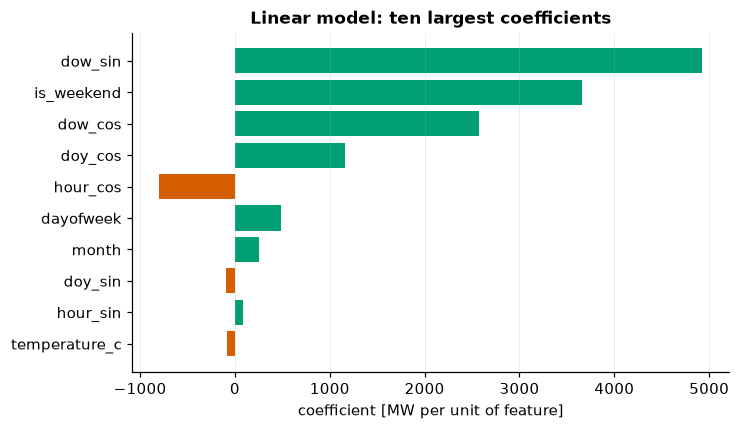

Interpretable, and the signs are physically sensible — but be careful: with
correlated lags, individual coefficients are not stable and should not be
read as causal effects.


In [13]:
coefficients = pd.Series(sklearn_model.coef_, index=X_train.columns).sort_values(key=abs, ascending=False)
fig, ax = plt.subplots(figsize=(7, 4))
top = coefficients.head(10)[::-1]
ax.barh(top.index, top.to_numpy(), color=[COLORS["tree"] if v > 0 else COLORS["transformer"] for v in top])
ax.set_xlabel("coefficient [MW per unit of feature]")
ax.set_title("Linear model: ten largest coefficients")
ax.grid(axis="y", visible=False)
plt.show()

print("Interpretable, and the signs are physically sensible — but be careful: with\n"
      "correlated lags, individual coefficients are not stable and should not be\n"
      "read as causal effects.")

## 10. Model comparison

Four hypothesis classes, identical features, identical split.

In [14]:
MODELS = {
    "Mean (DummyRegressor)": DummyRegressor(strategy="mean"),
    "Linear regression": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge (alpha=10)": make_pipeline(StandardScaler(), Ridge(alpha=10.0)),
    "Decision tree (depth 6)": DecisionTreeRegressor(max_depth=6, random_state=0),
    "Random forest": RandomForestRegressor(
        n_estimators=scaled(full=200, fast=40), max_depth=14,
        random_state=0, n_jobs=-1, min_samples_leaf=4,
    ),
    "Gradient boosting": HistGradientBoostingRegressor(
        max_iter=scaled(full=400, fast=60), learning_rate=0.06,
        max_depth=None, early_stopping=False, random_state=0,
    ),
}

predictions: dict[str, np.ndarray] = {}
rows = []
for name, model in MODELS.items():
    set_seed()
    model.fit(X_train, y_train)
    valid_prediction = model.predict(X_valid)
    test_prediction = model.predict(X_test)
    predictions[name] = test_prediction
    rows.append(
        {
            "Model": name,
            "MAE_valid": mae(y_valid, valid_prediction),
            **point_metrics(y_test, test_prediction),
            "Skill_vs_baseline": skill_score(y_test, test_prediction, reference),
        }
    )

comparison = pd.DataFrame(rows).set_index("Model")
display(comparison.round(3))

,MAE_valid,MAE,RMSE,R2,Bias,MAPE_%,Skill_vs_baseline
Model,,,,,,,
Mean (DummyRegressor),5622.156,5549.629,6851.965,-0.018,923.447,10.880,-1.320
Linear regression,2097.222,2066.153,2651.899,0.847,359.230,3.892,0.102
Ridge (alpha=10),2097.584,2066.638,2652.472,0.847,361.064,3.893,0.102
Decision tree (depth 6),1983.780,1888.431,2553.845,0.859,158.931,3.566,0.135
Random forest,1694.019,1636.504,2260.824,0.889,228.205,3.067,0.234
Gradient boosting,1708.141,1776.462,2400.515,0.875,574.800,3.345,0.187


### The comparison that matters

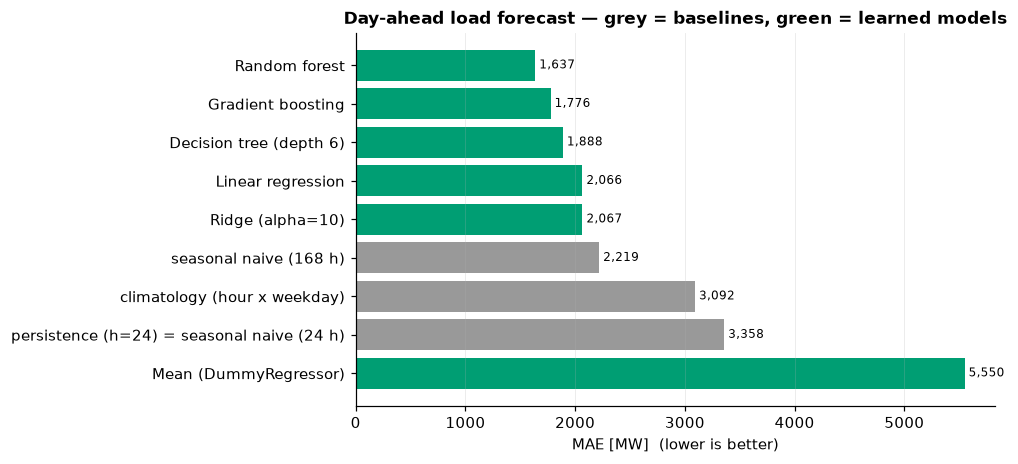

,MAE,RMSE,Skill vs. best baseline
Random forest,1636.504,2260.824,0.234
Gradient boosting,1776.462,2400.515,0.187
Decision tree (depth 6),1888.431,2553.845,0.135
Linear regression,2066.153,2651.899,0.102
Ridge (alpha=10),2066.638,2652.472,0.102
seasonal naive (168 h),2218.972,2952.957,0.000
climatology (hour x weekday),3092.499,3623.821,-0.227
persistence (h=24) = seasonal naive (24 h),3358.186,4600.202,-0.558
Mean (DummyRegressor),5549.629,6851.965,-1.320


In [15]:
everything = {**{k: v.to_numpy() for k, v in baselines.items()}, **predictions}
summary = pd.DataFrame(
    {name: {"MAE": mae(y_test, p), "RMSE": rmse(y_test, p),
            "Skill vs. best baseline": skill_score(y_test, p, reference)}
     for name, p in everything.items()}
).T.sort_values("MAE")

fig, ax = plt.subplots(figsize=(7.5, 4.4))
colors = [COLORS["baseline"] if name in baselines else COLORS["tree"] for name in summary.index]
ax.barh(summary.index, summary.MAE, color=colors)
ax.invert_yaxis()
ax.set_xlabel("MAE [MW]  (lower is better)")
ax.set_title("Day-ahead load forecast — grey = baselines, green = learned models")
ax.grid(axis="y", visible=False)
for y_pos, value in enumerate(summary.MAE):
    ax.text(value, y_pos, f" {value:,.0f}", va="center", fontsize=8)
plt.show()

display(summary.round(3))

In [16]:
winner = summary.index[0]
linear_mae = summary.loc["Linear regression", "MAE"]

print(f"Best model      : {winner}  (MAE {summary.MAE.iloc[0]:,.0f} MW)")
print(f"Best baseline   : {reference_name}  (MAE {mae(y_test, reference):,.0f} MW)")
print(f"Best vs. linear : {1 - summary.MAE.iloc[0] / linear_mae:.1%} lower MAE")
print(f"Best vs. mean   : {1 - summary.MAE.iloc[0] / summary.loc['Mean (DummyRegressor)', 'MAE']:.1%} lower MAE")

Best model      : Random forest  (MAE 1,637 MW)
Best baseline   : seasonal naive (168 h)  (MAE 2,219 MW)
Best vs. linear : 20.8% lower MAE
Best vs. mean   : 70.5% lower MAE


Three things to take from this chart.

1. **The tree ensembles win.** Random forests and gradient boosting are close
   to each other and clearly ahead of the linear model, because the non-linear
   temperature response and the hour-of-day x weekday interaction are exactly
   what trees represent well. Which of the two ensembles comes first depends on
   hyper-parameters and on the dataset; treat a gap of a few percent between
   them as noise unless you have cross-validated it.
2. **The mean predictor is catastrophic and the seasonal naive is not.** Had
   you reported $R^2$ against the mean, you would have declared victory long
   before doing anything useful. Skill against a *seasonal* baseline is the
   number that carries information.
3. **Persistence and the 24-hour seasonal naive collapsed into one row.** At a
   24-hour horizon on hourly data they are literally the same forecast. The
   baseline suite detects the duplication and says so, rather than padding the
   table with the same idea twice. Note also which baseline won: "the same
   hour *last week*" beats "the same hour yesterday", because it gets the
   weekday right. Choosing the seasonal period is itself domain knowledge.

## 11. Bias, variance and overfitting — measured

Tree depth is a clean complexity knob: depth 1 is a stump (high bias), depth
30 memorises the training set (high variance). Watch the two curves separate.

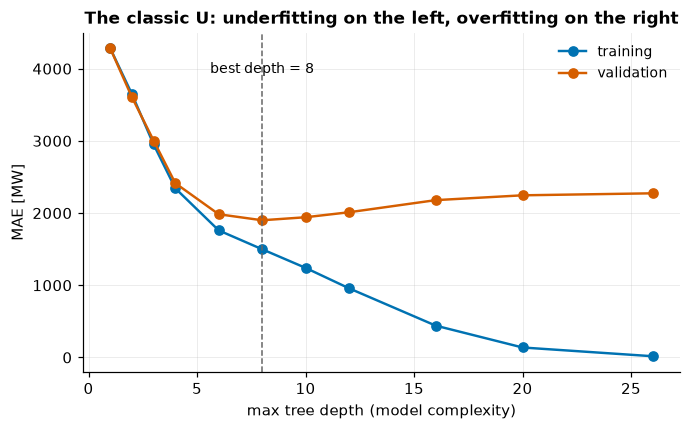

,train MAE,validation MAE,leaves
depth,,,
1,4283.4,4282.9,2
2,3649.3,3606.3,4
3,2950.3,3003.8,8
4,2343.1,2414.0,16
6,1760.3,1983.8,64
8,1499.1,1900.4,255
10,1241.2,1942.1,896
12,958.8,2011.1,2353
16,440.7,2179.2,7552


In [17]:
depths = [1, 2, 3, 4, 6, 8, 10, 12, 16, 20, 26]
curve = []
for depth in depths:
    tree = DecisionTreeRegressor(max_depth=depth, random_state=0).fit(X_train, y_train)
    curve.append(
        {
            "depth": depth,
            "train MAE": mae(y_train, tree.predict(X_train)),
            "validation MAE": mae(y_valid, tree.predict(X_valid)),
            "leaves": tree.get_n_leaves(),
        }
    )
curve = pd.DataFrame(curve).set_index("depth")

best_depth = int(curve["validation MAE"].idxmin())
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(curve.index, curve["train MAE"], marker="o", label="training", color=COLORS["rnn"])
ax.plot(curve.index, curve["validation MAE"], marker="o", label="validation", color=COLORS["transformer"])
ax.axvline(best_depth, ls="--", color="#666", lw=1)
ax.annotate(f"best depth = {best_depth}", (best_depth, curve["validation MAE"].max() * 0.92),
            ha="center", fontsize=9)
ax.set_xlabel("max tree depth (model complexity)")
ax.set_ylabel("MAE [MW]")
ax.set_title("The classic U: underfitting on the left, overfitting on the right")
ax.legend()
plt.show()

display(curve.round(1))

The training error decreases monotonically — it always does, which is why
training error is worthless for model selection. Validation error turns
around. The gap between the curves *is* the variance: at depth 26 the tree
reproduces the training set almost exactly and has learned nothing
transferable.

Note that the comparison table above used a fixed depth of 6, while the
validation curve prefers a deeper tree. That is deliberate: the table shows a
reasonable default, and this curve shows how you would improve on it. A single
tuned tree still loses to the ensembles, which is the more important point.

Crucially, the depth was chosen on **validation** data. The test set has still
not been used for any decision.

## 12. Cross-validation, done correctly for time series

$k$-fold cross-validation assumes exchangeable samples. Time series are not
exchangeable. `TimeSeriesSplit` instead grows the training window forward, so
every fold trains on the past and validates on the future.

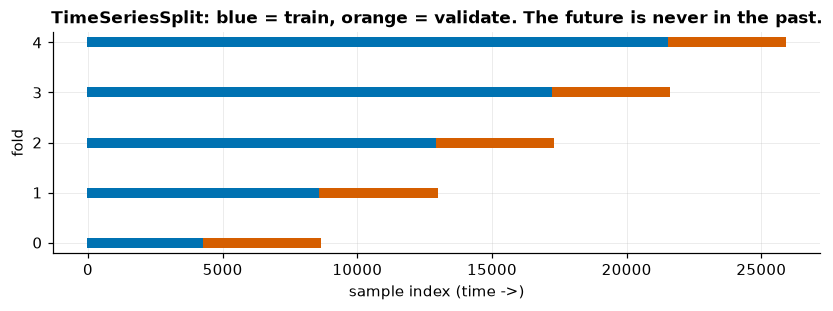

  fold 0: MAE  1859.9 MW
  fold 1: MAE  1962.5 MW
  fold 2: MAE  1520.7 MW
  fold 3: MAE  1762.6 MW
  fold 4: MAE  1626.5 MW

  mean  1746.4 MW  (std 158.2)

The spread across folds is the honest uncertainty on the estimate. A single
train/test number without it invites over-reading small differences.


In [18]:
splitter = TimeSeriesSplit(n_splits=5)
fig, ax = plt.subplots(figsize=(9, 2.6))
for fold, (train_index, valid_index) in enumerate(splitter.split(X_all)):
    ax.plot(train_index, np.full_like(train_index, fold, dtype=float), "|", color=COLORS["rnn"], ms=6)
    ax.plot(valid_index, np.full_like(valid_index, fold, dtype=float), "|", color=COLORS["transformer"], ms=6)
ax.set_yticks(range(5))
ax.set_ylabel("fold")
ax.set_xlabel("sample index (time ->)")
ax.set_title("TimeSeriesSplit: blue = train, orange = validate. The future is never in the past.")
plt.show()

cv_scores = -cross_val_score(
    HistGradientBoostingRegressor(max_iter=scaled(full=200, fast=40), random_state=0),
    X_all, y_all, cv=splitter, scoring="neg_mean_absolute_error",
)
for fold, score in enumerate(cv_scores):
    print(f"  fold {fold}: MAE {score:7.1f} MW")
print(f"\n  mean {cv_scores.mean():7.1f} MW  (std {cv_scores.std():.1f})")
print("\nThe spread across folds is the honest uncertainty on the estimate. A single\n"
      "train/test number without it invites over-reading small differences.")

## 13. Inspect the model

Where does gradient boosting get its skill from?

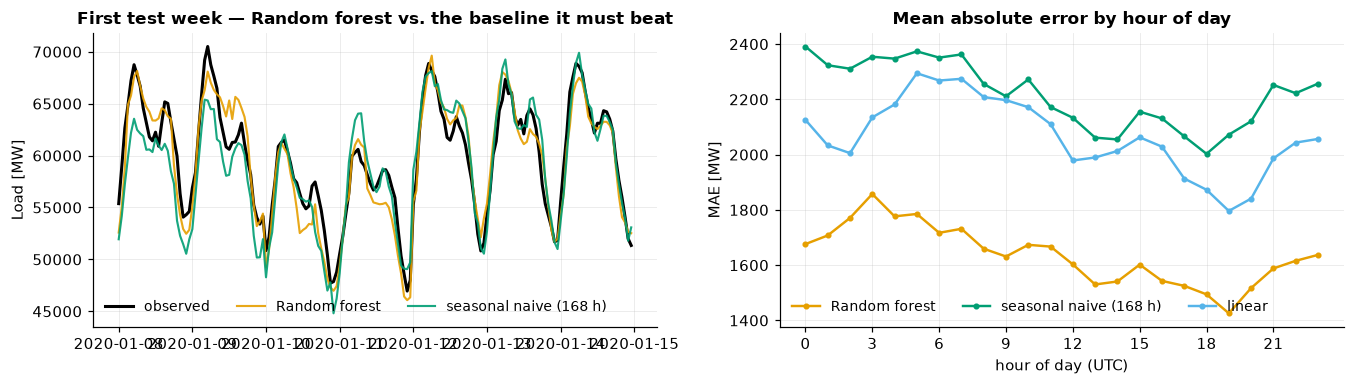

In [19]:
best_name = summary.index[0]
best_prediction = everything[best_name]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.6))
window = slice(0, 168)
plot_forecast(
    y_test.iloc[window],
    {best_name: best_prediction[window], reference_name: reference.to_numpy()[window]},
    index=y_test.index[window],
    title=f"First test week — {best_name} vs. the baseline it must beat",
    ax=axes[0],
)
plot_error_by_hour(
    y_test.to_numpy(),
    {best_name: best_prediction, reference_name: reference.to_numpy(),
     "linear": predictions["Linear regression"]},
    hours=y_test.index.hour.to_numpy(),
    ax=axes[1],
)
fig.tight_layout()
plt.show()

The right panel is the more informative one. Errors are far from uniform over
the day: the morning and evening ramps are where the models differ, and the
night is where everyone is right. An aggregate MAE hides both facts.

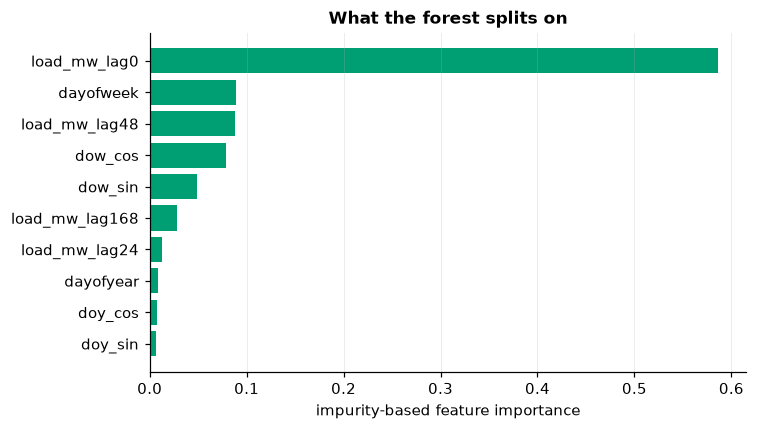

Health warning: impurity-based importance is biased towards high-cardinality
features and splits correlated features arbitrarily between them. Use permutation
importance when the answer matters.


In [20]:
importance = pd.Series(
    RandomForestRegressor(n_estimators=scaled(full=120, fast=30), max_depth=12,
                          random_state=0, n_jobs=-1).fit(X_train, y_train).feature_importances_,
    index=X_train.columns,
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
top = importance.head(10)[::-1]
ax.barh(top.index, top.to_numpy(), color=COLORS["tree"])
ax.set_xlabel("impurity-based feature importance")
ax.set_title("What the forest splits on")
ax.grid(axis="y", visible=False)
plt.show()

print("Health warning: impurity-based importance is biased towards high-cardinality\n"
      "features and splits correlated features arbitrarily between them. Use permutation\n"
      "importance when the answer matters.")

## 14. Statistical accuracy is not physical plausibility

A theme of this whole course. Load cannot be negative, and the national load
cannot change by 30 GW in an hour. Does the winning model respect that?

In [21]:
observed_max_ramp = np.abs(np.diff(frame.load_mw.to_numpy())).max()

physics = pd.DataFrame(
    {
        name: physical_violations(
            values, lower_bound=0.0, upper_bound=None, max_ramp=observed_max_ramp
        )
        for name, values in everything.items()
    }
).T
display(physics.round(4))

print(f"Largest hourly ramp ever observed in the data: {observed_max_ramp:,.0f} MW\n")

offenders = physics[physics.ramp_violation_rate > 0]
print("Negative-load predictions: "
      f"{'none' if physics.below_min_rate.max() == 0 else 'PRESENT'}")
if offenders.empty:
    print("Implausible ramps: none.")
else:
    for name, row in offenders.iterrows():
        print(f"Implausible ramps: {name} exceeds the observed maximum in "
              f"{row.ramp_violation_rate:.2%} of hours, worst {row.worst_ramp:,.0f} MW.")
print("\nLoad is strictly positive and smooth, so the sign constraint is never binding.\n"
      "The ramp constraint is a different story: a single deep decision tree can jump\n"
      "between leaves and produce a step no power system could follow. Ensembles average\n"
      "that away, which is a physical argument for ensembling, not just a statistical one.")

,below_min_rate,worst_below_min,ramp_violation_rate,worst_ramp
persistence (h=24) = seasonal naive (24 h),0.0,0.0,0.0000,9475.8370
seasonal naive (168 h),0.0,0.0,0.0000,9475.8370
climatology (hour x weekday),0.0,0.0,0.0000,7462.7996
Mean (DummyRegressor),0.0,0.0,0.0000,0.0000
Linear regression,0.0,0.0,0.0000,7644.0173
Ridge (alpha=10),0.0,0.0,0.0000,7598.8363
Decision tree (depth 6),0.0,0.0,0.0007,14522.5155
Random forest,0.0,0.0,0.0000,9284.2438
Gradient boosting,0.0,0.0,0.0000,9496.6943


Largest hourly ramp ever observed in the data: 10,111 MW

Negative-load predictions: none
Implausible ramps: Decision tree (depth 6) exceeds the observed maximum in 0.07% of hours, worst 14,523 MW.

Load is strictly positive and smooth, so the sign constraint is never binding.
The ramp constraint is a different story: a single deep decision tree can jump
between leaves and produce a step no power system could follow. Ensembles average
that away, which is a physical argument for ensembling, not just a statistical one.


### Now try a quantity where the physics bites

PV generation is exactly zero at night. There is no statistical subtlety here:
a non-zero prediction at 02:00 is *wrong*, regardless of how small it is.

In [22]:
pv_train, pv_valid, pv_test = time_split(frame)
Xp_train, yp_train = make_supervised(pv_train, target="pv_mw", horizon=HORIZON)
Xp_test, yp_test = make_supervised(pv_test, target="pv_mw", horizon=HORIZON)

pv_model = make_pipeline(StandardScaler(), LinearRegression()).fit(Xp_train, yp_train)
pv_prediction = pv_model.predict(Xp_test)

night = frame.loc[yp_test.index, "clear_sky_index"].to_numpy() <= 0.0
pv_physics = physical_violations(
    pv_prediction, lower_bound=0.0, upper_bound=45_000.0, zero_mask=night
)

print(f"PV day-ahead forecast (linear model)   MAE {mae(yp_test, pv_prediction):,.0f} MW"
      f"   R2 {point_metrics(yp_test, pv_prediction)['R2']:.3f}")
print("\nphysical checks:")
for key, value in pv_physics.items():
    print(f"  {key:32s} {value:12,.3f}")
print(f"\n{pv_physics['below_min_rate']:.1%} of predictions are NEGATIVE generation, and "
      f"{pv_physics['nonzero_when_impossible_rate']:.1%}\nof night hours get a non-zero PV "
      "forecast — the worst by "
      f"{pv_physics['worst_impossible_value']:,.0f} MW.\n\n"
      "The R2 looks respectable. The model is nonetheless producing states that cannot\n"
      "physically occur. No statistical metric in this notebook would have told you.")

PV day-ahead forecast (linear model)   MAE 1,879 MW   R2 0.812

physical checks:
  below_min_rate                          0.253
  worst_below_min                    -1,540.847
  above_max_rate                          0.000
  worst_above_max                         0.000
  nonzero_when_impossible_rate            1.000
  worst_impossible_value              2,944.082

25.3% of predictions are NEGATIVE generation, and 100.0%
of night hours get a non-zero PV forecast — the worst by 2,944 MW.

The R2 looks respectable. The model is nonetheless producing states that cannot
physically occur. No statistical metric in this notebook would have told you.


The fix is not a better model — it is a *constraint*. Clipping at zero and
forcing night hours to zero costs nothing and removes every violation:

In [23]:
constrained = np.clip(pv_prediction, 0.0, 45_000.0)
constrained[night] = 0.0

print(f"unconstrained  MAE {mae(yp_test, pv_prediction):8,.1f} MW")
print(f"constrained    MAE {mae(yp_test, constrained):8,.1f} MW   "
      f"({skill_score(yp_test, constrained, pv_prediction):.1%} better, and physically valid)")
print("\nPhysical knowledge is free accuracy. This is the single cheapest improvement\n"
      "available in applied energy forecasting, and it is routinely skipped.")

unconstrained  MAE  1,878.8 MW
constrained    MAE  1,591.0 MW   (1.5% better, and physically valid)

Physical knowledge is free accuracy. This is the single cheapest improvement
available in applied energy forecasting, and it is routinely skipped.


## 15. Failure analysis

When is the best model worst?

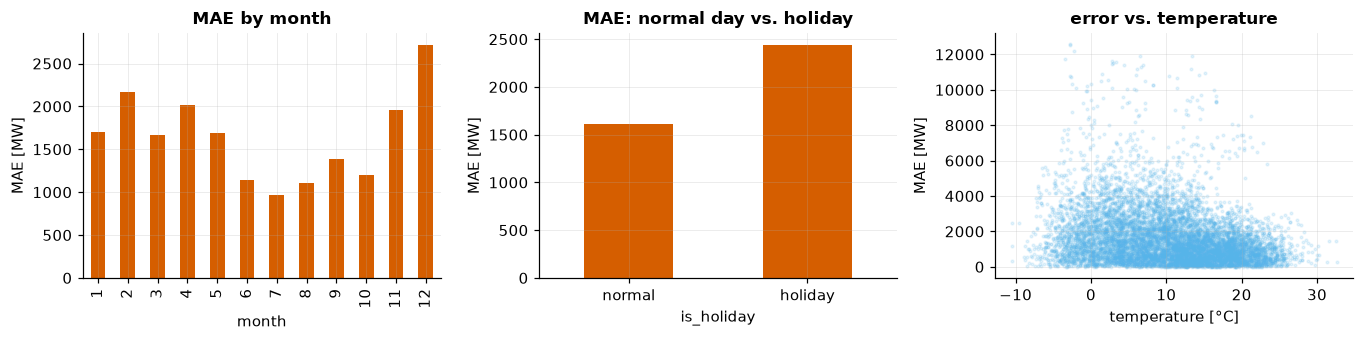

Eight worst hours:


,absolute_error,observed,hour,dayofweek,month,is_holiday,temperature
time,,,,,,,
2020-12-30 03:00:00+00:00,12571.4,51457.6,3,2,12,False,-2.8
2020-12-30 04:00:00+00:00,12539.6,54043.6,4,2,12,False,-2.8
2020-12-30 05:00:00+00:00,12202.4,55795.8,5,2,12,False,-2.3
2020-04-30 09:00:00+00:00,11927.6,47686.1,9,3,4,False,13.3
2020-12-30 15:00:00+00:00,11923.4,51139.4,15,2,12,False,6.5
2020-12-30 00:00:00+00:00,11761.2,43651.7,0,2,12,False,-3.4
2020-12-27 09:00:00+00:00,11622.9,65462.3,9,6,12,False,2.7
2020-12-30 11:00:00+00:00,11543.9,51721.9,11,2,12,False,3.3



Holidays are 1.5x harder than normal days. There are few of them,
so they barely move the aggregate MAE — and they are exactly the days an operator
cares about. Aggregate metrics systematically under-weight rare, important regimes.


In [24]:
errors = pd.DataFrame(
    {
        "absolute_error": np.abs(y_test.to_numpy() - best_prediction),
        "observed": y_test.to_numpy(),
        "hour": y_test.index.hour,
        "dayofweek": y_test.index.dayofweek,
        "month": y_test.index.month,
        "is_holiday": frame.loc[y_test.index, "is_holiday"].to_numpy(),
        "temperature": frame.loc[y_test.index, "temperature_c"].to_numpy(),
    },
    index=y_test.index,
)

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.2))
errors.groupby("month").absolute_error.mean().plot(
    kind="bar", ax=axes[0], color=COLORS["transformer"], title="MAE by month")
errors.groupby("is_holiday").absolute_error.mean().plot(
    kind="bar", ax=axes[1], color=COLORS["transformer"], title="MAE: normal day vs. holiday")
axes[1].set_xticklabels(["normal", "holiday"], rotation=0)
axes[2].scatter(errors.temperature, errors.absolute_error, s=3, alpha=0.15, color=COLORS["mlp"])
axes[2].set_title("error vs. temperature")
axes[2].set_xlabel("temperature [°C]")
for ax in axes:
    ax.set_ylabel("MAE [MW]")
fig.tight_layout()
plt.show()

worst = errors.nlargest(8, "absolute_error")
print("Eight worst hours:")
display(worst.round(1))

holiday_penalty = (
    errors.loc[errors.is_holiday, "absolute_error"].mean()
    / errors.loc[~errors.is_holiday, "absolute_error"].mean()
)
print(f"\nHolidays are {holiday_penalty:.1f}x harder than normal days. There are few of them,\n"
      "so they barely move the aggregate MAE — and they are exactly the days an operator\n"
      "cares about. Aggregate metrics systematically under-weight rare, important regimes.")

## 16. Record the result

Every tutorial appends to a shared leaderboard so that tutorial 10 can show
the whole progression. Nothing is hard-coded: the table only ever contains
experiments that were actually executed.

In [25]:
# Clear this tutorial's own rows first, so re-running the notebook replaces its
# results instead of accumulating stale ones. Other tutorials' rows are left
# untouched — the table is meant to survive an out-of-order run.
Leaderboard().clear(tutorial=1)

for name in ["Linear regression", "Gradient boosting", "Random forest"]:
    record(
        model=name,
        tutorial=1,
        metrics={
            **point_metrics(y_test, predictions[name]),
            "Skill": skill_score(y_test, predictions[name], reference),
        },
        notes="engineered lag + calendar features",
    )
for baseline_name, baseline_values in baselines.items():
    record(
        model=baseline_name,
        tutorial=1,
        metrics={
            **point_metrics(y_test, baseline_values),
            "Skill": skill_score(y_test, baseline_values, reference),
        },
        notes="trivial baseline",
    )

display(leaderboard_table())

print("\nThis table is the spine of the course. Tutorials 02, 03, 06 and 09 append to\n"
      "it, and tutorial 10 prints the finished version. It only ever contains rows from\n"
      "experiments that were actually executed — a tutorial you skip leaves a gap, it\n"
      "does not leave a guess.")

Bias       MAE  \
Tutorial Model                                                           
1        Random forest                               228.205  1636.504   
         Gradient boosting                           574.800  1776.462   
         Linear regression                           359.230  2066.153   
         seasonal naive (168 h)                       51.785  2218.972   
         climatology (hour x weekday)                973.565  3092.499   
         persistence (h=24) = seasonal naive (24 h)   30.224  3358.186   

                                                     MAPE_%     R2      RMSE  \
Tutorial Model                                                                 
1        Random forest                                3.067  0.889  2260.824   
         Gradient boosting                            3.345  0.875  2400.515   
         Linear regression                            3.892  0.847  2651.899   
         seasonal naive (168 h)                       4.130  0.811  2952.957   
         climatology (hour x weekday)                 5.864  0.715  3623.821   
         persistence (h=24) = seasonal naive (24 h)   6.372  0.541  4600.202   

                                                     Skill  \
Tutorial Model                                               
1        Random forest                               0.234   
         Gradient boosting                           0.187   
         Linear regression                           0.102   
         seasonal naive (168 h)                      0.000   
         climatology (hour x weekday)               -0.227   
         persistence (h=24) = seasonal naive (24 h) -0.558   

                                                                                  Notes  
Tutorial Model                                                                           
1        Random forest                               engineered lag + calendar features  
         Gradient boosting                           engineered lag + calendar features  
         Linear regression                           engineered lag + calendar features  
         seasonal naive (168 h)                                        trivial baseline  
         climatology (hour x weekday)                                  trivial baseline  
         persistence (h=24) = seasonal naive (24 h)                    trivial baseline


This table is the spine of the course. Tutorials 02, 03, 06 and 09 append to
it, and tutorial 10 prints the finished version. It only ever contains rows from
experiments that were actually executed — a tutorial you skip leaves a gap, it
does not leave a guess.


## 17. Exercises

**1 — Conceptual.** The `temperature_c` feature is the measured temperature at
the forecast origin, not a forecast for the target hour. Argue both sides:
when is using the measurement a *legitimate* modelling choice, and when does
it silently inflate the reported skill? Design an experiment that would
quantify the difference without needing a real weather forecast. (Hint: you
can simulate forecast error by adding noise whose magnitude grows with the
horizon.)

**2 — Coding.** The seasonal-naive baseline uses a 24-hour season. Build a
*weekly* naive baseline (`season=168`) and a blended one that uses the weekly
value on Mondays and holidays and the daily value otherwise. Does the blend
beat gradient boosting on holidays specifically? Report MAE on holiday hours
and on normal hours separately.

**3 — Research.** Re-run this entire notebook on the real Open Power System
Data series (`uv run python scripts/download_data.py`, then
`load_energy_data(source="opsd")`). Which conclusions survive and which do
not? Pay particular attention to the ranking of the models and to the size of
the gap between the best model and the best trivial baseline. Write down,
before you run it, what you expect to change.

## 18. Key takeaways

- **The pipeline is `data -> human-engineered features -> one model -> one
  task`.** Everything that follows in this course attacks one of those arrows.
- **A chronological split is not a style preference.** A shuffled split
  flattered a Ridge model by a double-digit percentage here, with no error
  and no warning sign.
- **The baseline determines whether a result is a result.** Seasonal naive is
  strong; the mean is not; report skill against the former.
- **Gradient boosting is a serious opponent.** It won this notebook, it will
  win some of the next ones, and "we used deep learning" is not an argument.
- **Statistical validity and physical validity are different questions.** The
  PV model had a respectable $R^2$ while predicting negative generation at
  night. Ask both questions, always.

## 19. Further reading

- Hastie, Tibshirani & Friedman, *The Elements of Statistical Learning*, ch. 2
  and 7 — bias/variance and model assessment. <https://hastie.su.domains/ElemStatLearn/>
- Hyndman & Athanasopoulos, *Forecasting: Principles and Practice*, 3rd ed.,
  ch. 5 — why simple benchmarks are hard to beat. <https://otexts.com/fpp3/>
- Kapoor & Narayanan, "Leakage and the Reproducibility Crisis in ML-based
  Science", *Patterns* 4(9), 2023. [arXiv:2207.07048](https://arxiv.org/abs/2207.07048)
- Makridakis et al., "The M4 Competition", *IJF* 36(1), 2020 — the empirical
  record on complex methods losing to simple ones.
- Breiman, "Random Forests", *Machine Learning* 45, 2001.

---

**Next:** [Tutorial 02 — Neural Networks and Backpropagation](02_neural_networks.ipynb),
in which we stop engineering the non-linearity by hand and make the model
learn it — and find out whether that is actually an improvement.